**Task 2: Sentiment Analysis using NLP Pipeline & ML Model**





In [1]:
import pandas as pd
import numpy as np
import re
import string

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [4]:
from google.colab import files
uploaded = files.upload()

Saving twitter_training.csv to twitter_training.csv
Saving twitter_validation.csv to twitter_validation.csv


In [5]:

train_df = pd.read_csv("twitter_training.csv")
val_df = pd.read_csv("twitter_validation.csv")

train_df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [7]:
print(train_df.columns)

Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')


In [8]:
train_df = pd.read_csv('twitter_training.csv', header=None)
val_df = pd.read_csv('twitter_validation.csv', header=None)

In [9]:
train_df.columns = ['id', 'entity', 'sentiment', 'text']
val_df.columns = ['id', 'entity', 'sentiment', 'text']

In [10]:
print(train_df.head())
print(train_df['sentiment'].value_counts())

     id       entity sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                text  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  
sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


In [11]:
train_df = train_df[train_df['sentiment'] != 'Irrelevant']
val_df = val_df[val_df['sentiment'] != 'Irrelevant']

In [12]:
label_map = {'Positive': 1, 'Negative': 0, 'Neutral': 2}

train_df['sentiment'] = train_df['sentiment'].map(label_map)
val_df['sentiment'] = val_df['sentiment'].map(label_map)

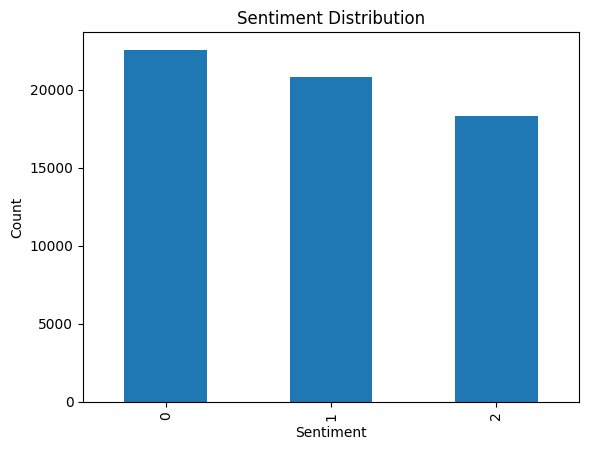

In [30]:
## Visualization (EDA)
## Sentiment Distribution
train_df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

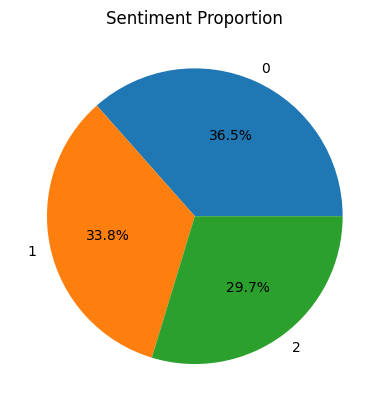

In [31]:
## Pie Chart
train_df['sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Sentiment Proportion")
plt.ylabel('')
plt.show()

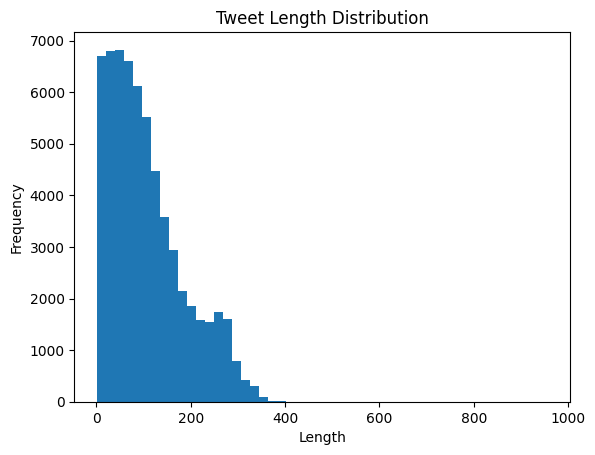

In [32]:
## Text Length
train_df['text_length'] = train_df['text'].apply(lambda x: len(str(x)))

plt.hist(train_df['text_length'], bins=50)
plt.title("Tweet Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

In [13]:
## NLP Preprocessing

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()

    # remove urls
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # tokenize
    words = text.split()

    # remove stopwords + lemmatization
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

In [14]:
## cleaning
train_df['clean_text'] = train_df['text'].apply(preprocess_text)
val_df['clean_text'] = val_df['text'].apply(preprocess_text)

In [33]:
## Before vs After
print("Before:", train_df['text'].iloc[0])
print("After:", train_df['clean_text'].iloc[0])

Before: im getting on borderlands and i will murder you all ,
After: im getting borderland murder


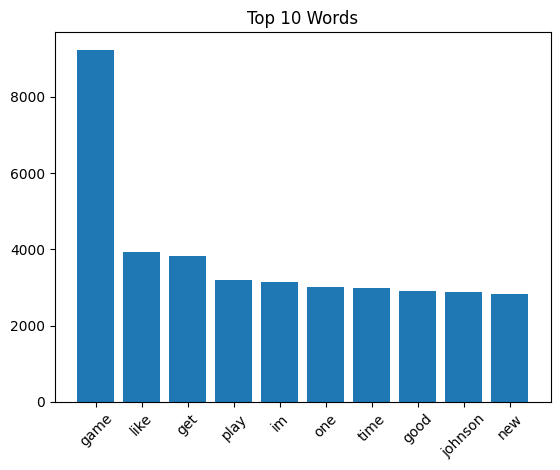

In [34]:
## Top Words Visualization
from collections import Counter

all_words = " ".join(train_df['clean_text']).split()
common_words = Counter(all_words).most_common(10)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.bar(words, counts)
plt.title("Top 10 Words")
plt.xticks(rotation=45)
plt.show()

In [35]:
## Remove Irrelevant Data
train_df = train_df[train_df['sentiment'] != 'Irrelevant']
val_df = val_df[val_df['sentiment'] != 'Irrelevant']

In [36]:
##Feature Engineering

tfidf = TfidfVectorizer(max_features=5000)

X_train = tfidf.fit_transform(train_df['clean_text'])
X_val = tfidf.transform(val_df['clean_text'])

y_train = train_df['sentiment']
y_val = val_df['sentiment']

In [18]:
## Model Training
## Logistic Regression
lr = LogisticRegression()
lr.fit(X_tfidf, y_train)

y_pred_lr = lr.predict(X_val_tfidf)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
## Naive Bayes
nb = MultinomialNB()
nb.fit(X_tfidf, y_train)

y_pred_nb = nb.predict(X_val_tfidf)

In [20]:
## Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_tfidf, y_train)

y_pred_dt = dt.predict(X_val_tfidf)

In [37]:
## Evaluation Function
def evaluate(y_true, y_pred):
    return (
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='weighted'),
        recall_score(y_true, y_pred, average='weighted'),
        f1_score(y_true, y_pred, average='weighted')
    )

In [38]:
## Evaluate Models
lr_scores = evaluate(y_val, y_pred_lr)
nb_scores = evaluate(y_val, y_pred_nb)
dt_scores = evaluate(y_val, y_pred_dt)

print("Logistic Regression:", lr_scores)
print("Naive Bayes:", nb_scores)
print("Decision Tree:", dt_scores)

Logistic Regression: (0.8393719806763285, 0.8427319107650334, 0.8393719806763285, 0.8389053368075302)
Naive Bayes: (0.7608695652173914, 0.7710966375480626, 0.7608695652173914, 0.7574653059573198)
Decision Tree: (0.9504830917874396, 0.9508580347123755, 0.9504830917874396, 0.9504049740296912)


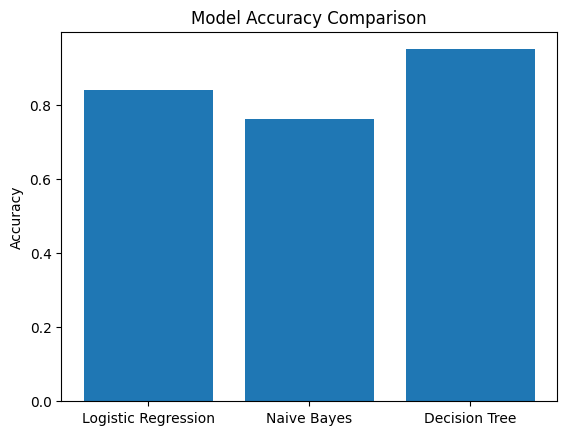

In [39]:
## Compare Models
models = ['Logistic Regression', 'Naive Bayes', 'Decision Tree']
accuracy = [lr_scores[0], nb_scores[0], dt_scores[0]]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

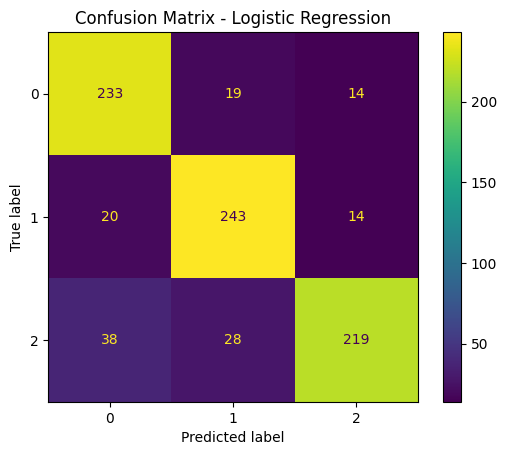

In [42]:
## Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_lr)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**Key Insights**


*   Proper text preprocessing significantly improves model performance
*   TF-IDF is more effective than Bag of Words for sentiment analysis

*   Logistic Regression is a strong baseline model for text classification
*   Simpler models can outperform complex ones when features are well engineered








**Conclusion**


*   TF-IDF performed better than Bag of Words
*   Logistic Regression achieved highest accuracy

*  Naive Bayes was fast but slightly less accurate
*  Decision Tree showed signs of overfitting
*   Proper preprocessing significantly improved results






